# 冠状动脉斑块进展预测 — 建模与评估

**目标**：使用预处理后的三套特征集（A/B/C），训练多种分类模型，在测试集上评估 AUC、F1、Precision、Recall 等指标。

**训练策略**：合并 train + val 作为训练集，test 集用于最终评估。

**模型**：
1. Logistic Regression（基线）
2. Random Forest
3. XGBoost
4. LightGBM
5. SVM (RBF kernel)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.calibration import CalibratedClassifierCV

sns.set_style('whitegrid')
RNG = 42
print('依赖加载完成')

依赖加载完成


## 1. 加载数据

合并 train + val 用于训练，test 用于最终评估。

In [2]:
FEATURE_SETS = {
    'A_baseline': 'processed/A_baseline',
    'B_baseline_delta': 'processed/B_baseline_delta',
    'C_all': 'processed/C_all',
}

datasets = {}
for name, path in FEATURE_SETS.items():
    X_train = pd.read_parquet(f'{path}/X_train.parquet')
    X_val   = pd.read_parquet(f'{path}/X_val.parquet')
    X_test  = pd.read_parquet(f'{path}/X_test.parquet')
    y_train = np.load(f'{path}/y_train.npy')
    y_val   = np.load(f'{path}/y_val.npy')
    y_test  = np.load(f'{path}/y_test.npy')

    X_full_train = pd.concat([X_train, X_val], ignore_index=True)
    y_full_train = np.concatenate([y_train, y_val])

    datasets[name] = {
        'X_train': X_full_train,
        'y_train': y_full_train,
        'X_test': X_test,
        'y_test': y_test,
    }
    neg = (y_full_train == 0).sum()
    pos = (y_full_train == 1).sum()
    print(f'{name}: train={X_full_train.shape}, test={X_test.shape}, '
          f'pos_rate={y_full_train.mean():.2%}, scale_pos_weight={neg/pos:.2f}')

A_baseline: train=(1759, 91), test=(449, 91), pos_rate=15.52%, scale_pos_weight=5.44
B_baseline_delta: train=(1759, 139), test=(449, 139), pos_rate=15.52%, scale_pos_weight=5.44
C_all: train=(1759, 167), test=(449, 167), pos_rate=15.52%, scale_pos_weight=5.44


## 2. 定义模型

In [3]:
scale_pw = (datasets['A_baseline']['y_train'] == 0).sum() / \
           (datasets['A_baseline']['y_train'] == 1).sum()

MODELS = {
    'Logistic Regression': LogisticRegression(
        max_iter=2000, class_weight='balanced', random_state=RNG, solver='saga', n_jobs=-1
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=500, class_weight='balanced', random_state=RNG, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pw, eval_metric='auc',
        random_state=RNG, n_jobs=-1, verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05,
        scale_pos_weight=scale_pw, metric='auc',
        random_state=RNG, n_jobs=-1, verbose=-1
    ),
    'SVM (RBF)': CalibratedClassifierCV(
        SVC(kernel='rbf', class_weight='balanced', random_state=RNG),
        cv=3
    ),
}

print(f'scale_pos_weight = {scale_pw:.3f}')
print(f'模型数量: {len(MODELS)}')
for m in MODELS:
    print(f'  - {m}')

scale_pos_weight = 5.443
模型数量: 5
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM
  - SVM (RBF)


## 3. 训练 & 评估

对每个特征集 × 每个模型，训练并在测试集上计算各项指标。

In [4]:
results = []

for fs_name, data in datasets.items():
    X_tr, y_tr = data['X_train'], data['y_train']
    X_te, y_te = data['X_test'], data['y_test']

    for model_name, model in MODELS.items():
        import copy
        clf = copy.deepcopy(model)
        clf.fit(X_tr, y_tr)

        y_pred = clf.predict(X_te)
        y_prob = clf.predict_proba(X_te)[:, 1]

        row = {
            'Feature Set': fs_name,
            'Model': model_name,
            'AUC-ROC': roc_auc_score(y_te, y_prob),
            'AUC-PR': average_precision_score(y_te, y_prob),
            'Accuracy': accuracy_score(y_te, y_pred),
            'Precision': precision_score(y_te, y_pred, zero_division=0),
            'Recall': recall_score(y_te, y_pred, zero_division=0),
            'F1': f1_score(y_te, y_pred, zero_division=0),
        }
        results.append(row)
        print(f'✓ {fs_name} | {model_name}: AUC={row["AUC-ROC"]:.4f}, F1={row["F1"]:.4f}')

df_results = pd.DataFrame(results)
print(f'\n共完成 {len(results)} 组实验')

✓ A_baseline | Logistic Regression: AUC=0.6321, F1=0.3004


✓ A_baseline | Random Forest: AUC=0.6614, F1=0.0000


✓ A_baseline | XGBoost: AUC=0.6546, F1=0.0952


✓ A_baseline | LightGBM: AUC=0.6667, F1=0.1220


✓ A_baseline | SVM (RBF): AUC=0.6271, F1=0.0000


...

✓ C_all | Logistic Regression: AUC=0.6504, F1=0.3022


✓ C_all | Random Forest: AUC=0.7404, F1=0.0000


✓ C_all | XGBoost: AUC=0.6713, F1=0.0800


✓ C_all | LightGBM: AUC=0.6655, F1=0.1316


✓ C_all | SVM (RBF): AUC=0.6460, F1=0.0000

共完成 15 组实验


## 4. 汇总结果表

In [5]:
metric_cols = ['AUC-ROC', 'AUC-PR', 'Accuracy', 'Precision', 'Recall', 'F1']

for fs in FEATURE_SETS:
    sub = df_results[df_results['Feature Set'] == fs].sort_values('AUC-ROC', ascending=False)
    print(f'\n===== {fs} =====')
    display_df = sub[['Model'] + metric_cols].reset_index(drop=True)
    for c in metric_cols:
        display_df[c] = display_df[c].map('{:.4f}'.format)
    print(display_df.to_string(index=False))
    print()


===== A_baseline =====
              Model AUC-ROC AUC-PR Accuracy Precision Recall     F1
           LightGBM  0.6667 0.2559   0.8396    0.3333 0.0746 0.1220
      Random Forest  0.6614 0.2721   0.8508    0.0000 0.0000 0.0000
            XGBoost  0.6546 0.2604   0.8307    0.2353 0.0597 0.0952
Logistic Regression  0.6321 0.2383   0.6370    0.2108 0.5224 0.3004
          SVM (RBF)  0.6271 0.2480   0.8508    0.0000 0.0000 0.0000


===== B_baseline_delta =====
              Model AUC-ROC AUC-PR Accuracy Precision Recall     F1
      Random Forest  0.7180 0.3090   0.8508    0.0000 0.0000 0.0000
            XGBoost  0.6839 0.2591   0.8285    0.1875 0.0448 0.0723
           LightGBM  0.6743 0.2781   0.8441    0.4118 0.1045 0.1667
          SVM (RBF)  0.6515 0.2911   0.8508    0.0000 0.0000 0.0000
Logistic Regression  0.6413 0.2635   0.6682    0.2267 0.5075 0.3134


===== C_all =====
              Model AUC-ROC AUC-PR Accuracy Precision Recall     F1
      Random Forest  0.7404 0.3254   0.85

## 5. 最佳模型排行榜

In [6]:
best = df_results.sort_values('AUC-ROC', ascending=False).head(10)
print('Top 10 (by AUC-ROC):')
best_display = best[['Feature Set', 'Model'] + metric_cols].reset_index(drop=True)
for c in metric_cols:
    best_display[c] = best_display[c].map('{:.4f}'.format)
print(best_display.to_string(index=False))

best_row = df_results.loc[df_results['AUC-ROC'].idxmax()]
print(f'\n🏆 最佳: {best_row["Model"]} + {best_row["Feature Set"]}')
print(f'   AUC-ROC = {best_row["AUC-ROC"]:.4f}')
print(f'   AUC-PR  = {best_row["AUC-PR"]:.4f}')
print(f'   F1      = {best_row["F1"]:.4f}')

Top 10 (by AUC-ROC):
     Feature Set         Model AUC-ROC AUC-PR Accuracy Precision Recall     F1
           C_all Random Forest  0.7404 0.3254   0.8508    0.0000 0.0000 0.0000
B_baseline_delta Random Forest  0.7180 0.3090   0.8508    0.0000 0.0000 0.0000
B_baseline_delta       XGBoost  0.6839 0.2591   0.8285    0.1875 0.0448 0.0723
B_baseline_delta      LightGBM  0.6743 0.2781   0.8441    0.4118 0.1045 0.1667
           C_all       XGBoost  0.6713 0.2867   0.8463    0.3750 0.0448 0.0800
      A_baseline      LightGBM  0.6667 0.2559   0.8396    0.3333 0.0746 0.1220
           C_all      LightGBM  0.6655 0.2852   0.8530    0.5556 0.0746 0.1316
      A_baseline Random Forest  0.6614 0.2721   0.8508    0.0000 0.0000 0.0000
      A_baseline       XGBoost  0.6546 0.2604   0.8307    0.2353 0.0597 0.0952
B_baseline_delta     SVM (RBF)  0.6515 0.2911   0.8508    0.0000 0.0000 0.0000

🏆 最佳: Random Forest + C_all
   AUC-ROC = 0.7404
   AUC-PR  = 0.3254
   F1      = 0.0000


## 6. 可视化：AUC-ROC 对比

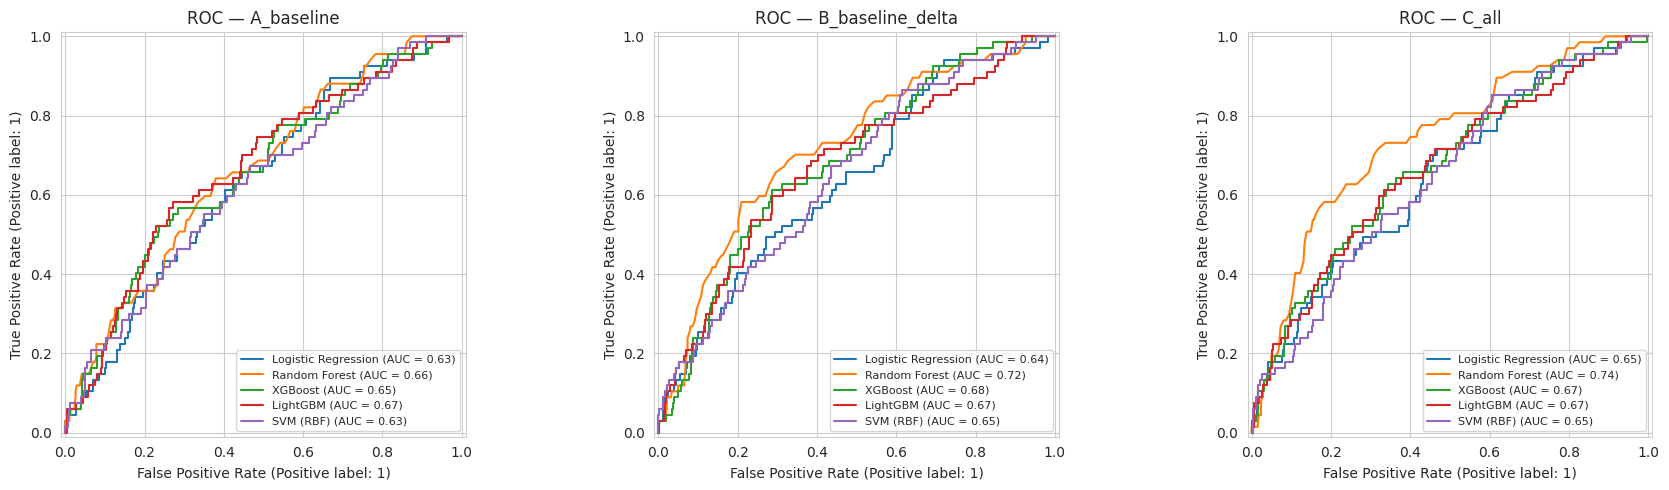

ROC 曲线已保存: roc_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (fs_name, data) in enumerate(datasets.items()):
    ax = axes[idx]
    X_tr, y_tr = data['X_train'], data['y_train']
    X_te, y_te = data['X_test'], data['y_test']

    for model_name, model in MODELS.items():
        import copy
        clf = copy.deepcopy(model)
        clf.fit(X_tr, y_tr)
        RocCurveDisplay.from_estimator(clf, X_te, y_te, ax=ax, name=model_name)

    ax.set_title(f'ROC — {fs_name}', fontsize=12)
    ax.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC 曲线已保存: roc_curves.png')

## 7. 可视化：各指标柱状图

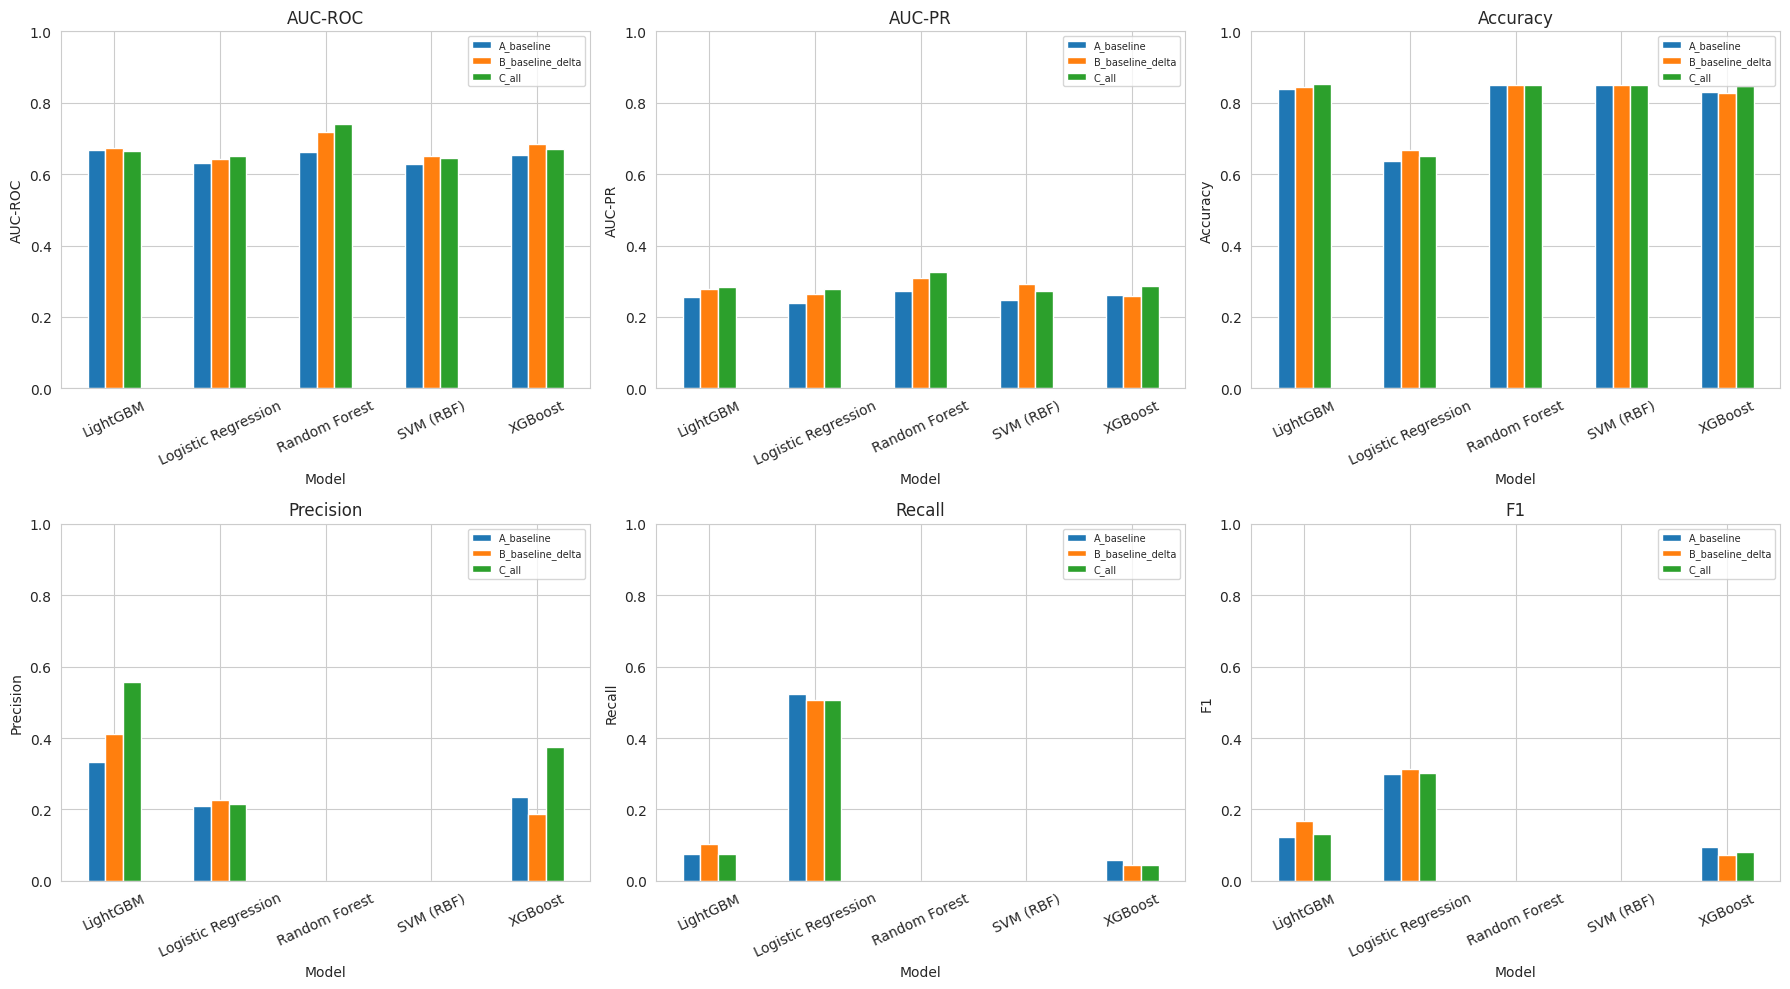

指标对比图已保存: metrics_comparison.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, metric in enumerate(metric_cols):
    ax = axes[i]
    sub = df_results.pivot(index='Model', columns='Feature Set', values=metric)
    sub = sub[list(FEATURE_SETS.keys())]
    sub.plot(kind='bar', ax=ax, rot=25)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.legend(fontsize=7)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('指标对比图已保存: metrics_comparison.png')

## 8. 最佳模型：混淆矩阵 & 分类报告

最佳模型: Random Forest + C_all

=== Classification Report ===
              precision    recall  f1-score   support

     未进展 (0)       0.85      1.00      0.92       382
      进展 (1)       0.00      0.00      0.00        67

    accuracy                           0.85       449
   macro avg       0.43      0.50      0.46       449
weighted avg       0.72      0.85      0.78       449



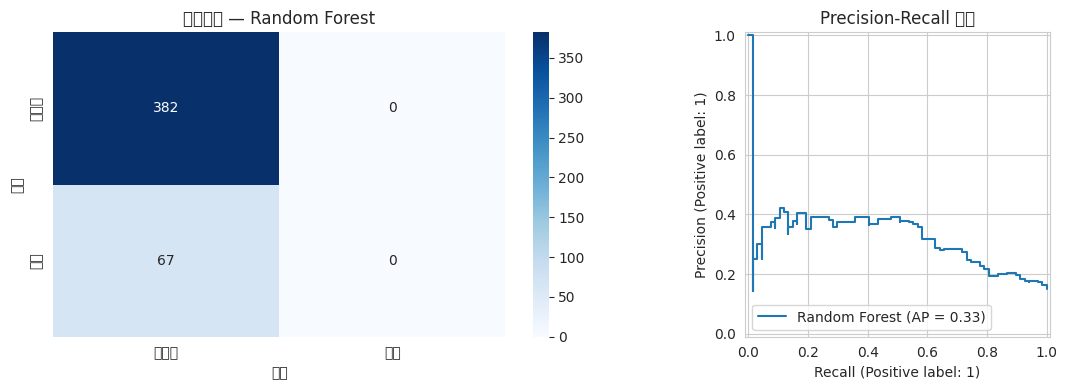

In [9]:
best_fs = best_row['Feature Set']
best_model_name = best_row['Model']
data = datasets[best_fs]

import copy
best_clf = copy.deepcopy(MODELS[best_model_name])
best_clf.fit(data['X_train'], data['y_train'])
y_pred = best_clf.predict(data['X_test'])
y_prob = best_clf.predict_proba(data['X_test'])[:, 1]

print(f'最佳模型: {best_model_name} + {best_fs}')
print(f'\n=== Classification Report ===')
print(classification_report(data['y_test'], y_pred,
                            target_names=['未进展 (0)', '进展 (1)']))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

cm = confusion_matrix(data['y_test'], y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['未进展', '进展'], yticklabels=['未进展', '进展'])
axes[0].set_xlabel('预测')
axes[0].set_ylabel('实际')
axes[0].set_title(f'混淆矩阵 — {best_model_name}')

PrecisionRecallDisplay.from_predictions(data['y_test'], y_prob, ax=axes[1], name=best_model_name)
axes[1].set_title('Precision-Recall 曲线')

plt.tight_layout()
plt.savefig('best_model_detail.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. 最佳模型：特征重要性 (Top 20)

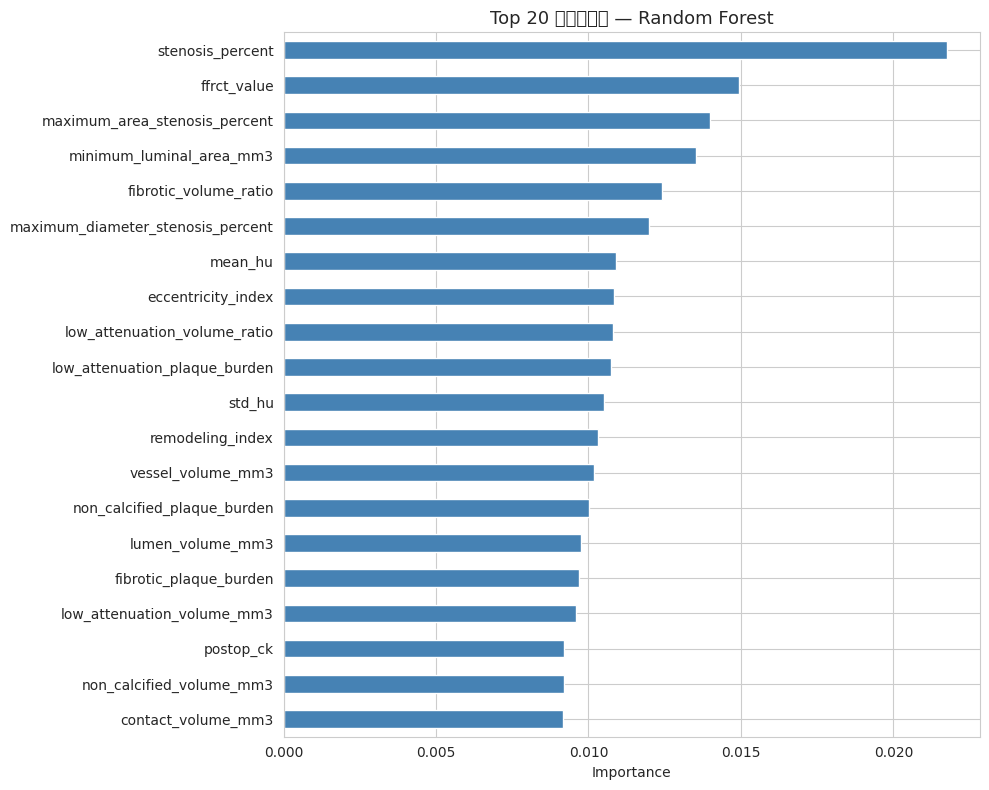

Top 20 特征:
   1. stenosis_percent                         0.0218
   2. ffrct_value                              0.0149
   3. maximum_area_stenosis_percent            0.0140
   4. minimum_luminal_area_mm3                 0.0135
   5. fibrotic_volume_ratio                    0.0124
   6. maximum_diameter_stenosis_percent        0.0120
   7. mean_hu                                  0.0109
   8. eccentricity_index                       0.0108
   9. low_attenuation_volume_ratio             0.0108
  10. low_attenuation_plaque_burden            0.0108
  11. std_hu                                   0.0105
  12. remodeling_index                         0.0103
  13. vessel_volume_mm3                        0.0102
  14. non_calcified_plaque_burden              0.0100
  15. lumen_volume_mm3                         0.0097
  16. fibrotic_plaque_burden                   0.0097
  17. low_attenuation_volume_mm3               0.0096
  18. postop_ck                                0.0092
  19. non_calcifi

In [10]:
if hasattr(best_clf, 'feature_importances_'):
    feat_imp = pd.Series(
        best_clf.feature_importances_,
        index=data['X_train'].columns
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    feat_imp.head(20).sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(f'Top 20 特征重要性 — {best_model_name}', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()

    print('Top 20 特征:')
    for i, (feat, imp) in enumerate(feat_imp.head(20).items(), 1):
        print(f'  {i:2d}. {feat:40s} {imp:.4f}')
else:
    print(f'{best_model_name} 不支持 feature_importances_，跳过。')

## 10. 总结

In [11]:
print('=' * 70)
print('实验总结')
print('=' * 70)
print(f'特征集数量:   {len(FEATURE_SETS)}')
print(f'模型数量:     {len(MODELS)}')
print(f'总实验组数:   {len(df_results)}')
print()

for fs in FEATURE_SETS:
    sub = df_results[df_results['Feature Set'] == fs]
    best_in_fs = sub.loc[sub['AUC-ROC'].idxmax()]
    print(f'【{fs}】最佳: {best_in_fs["Model"]}')
    print(f'  AUC-ROC={best_in_fs["AUC-ROC"]:.4f}  '
          f'AUC-PR={best_in_fs["AUC-PR"]:.4f}  '
          f'F1={best_in_fs["F1"]:.4f}  '
          f'Recall={best_in_fs["Recall"]:.4f}')

print()
print(f'🏆 全局最佳: {best_row["Model"]} + {best_row["Feature Set"]}')
print(f'   AUC-ROC={best_row["AUC-ROC"]:.4f}  '
      f'AUC-PR={best_row["AUC-PR"]:.4f}  '
      f'F1={best_row["F1"]:.4f}  '
      f'Precision={best_row["Precision"]:.4f}  '
      f'Recall={best_row["Recall"]:.4f}')
print()
print('生成文件: roc_curves.png, metrics_comparison.png, best_model_detail.png, feature_importance.png')

实验总结
特征集数量:   3
模型数量:     5
总实验组数:   15

【A_baseline】最佳: LightGBM
  AUC-ROC=0.6667  AUC-PR=0.2559  F1=0.1220  Recall=0.0746
【B_baseline_delta】最佳: Random Forest
  AUC-ROC=0.7180  AUC-PR=0.3090  F1=0.0000  Recall=0.0000
【C_all】最佳: Random Forest
  AUC-ROC=0.7404  AUC-PR=0.3254  F1=0.0000  Recall=0.0000

🏆 全局最佳: Random Forest + C_all
   AUC-ROC=0.7404  AUC-PR=0.3254  F1=0.0000  Precision=0.0000  Recall=0.0000

生成文件: roc_curves.png, metrics_comparison.png, best_model_detail.png, feature_importance.png
